# Гипотеза
Существует паттерн недобросовестных поставщиков, связанный с вероятностью срыва госконтракта и попадания компании в Реестр недобросовестных поставщиков.  
Вероятность возрастает при сочетании факторов:
- приближение уставного капитала к минимально допустимому;
- меньшее количество сотрудников;
- меньший возраст фирмы.


**Реестр недобросовестных поставщиков (ФАС России)**  

    [fas.gov.ru/opendata/7703516539-rnp](http://fas.gov.ru/opendata/7703516539-rnp)  
    Открытые данные (`CSV-реестр`).
    
    Целевая переменная (список мошенников).
    
    Содержит только ИНН и дату нарушения, нет финансовых показателей.
    
    Данные 2021 года.

**Сведения о среднесписочной численности работников (ФНС России)**

    [nalog.gov.ru/opendata/7707329152-sshr2019](http://nalog.gov.ru/opendata/7707329152-sshr2019)
    
    Полуструктурированные данные (`XML-архив`).
    
    Сведения о численности работников.
    
    >2200000 юридических лиц. Данные актуальны до 01.04.2026.

**Профили ЕГРЮЛ (API egrul.itsoft.ru)**  

    [https://egrul.itsoft.ru](https://egrul.itsoft.ru)  
    
    REST API (`JSON`).
    
    Уставный капитал, даты жизни компании.
    
    Бесплатно, но ограничение 100 запросов в день на айпи.


# 3. Сбор и предобработка данных

Процесс реализован в два этапа для оптимизации количества запросов к внешним API.

**Этап 1: Фильтрация совпадений**

Скачиваем реестр РНП и данные ФНС о численности сотрудников, находя пересечение ИНН.
Это позволяет запрашивать детальную информацию в API только по тем компаниям, которые гарантированно присутствуют в обоих источниках.



In [ ]:
import os
import xml.etree.ElementTree as ET
import csv
import urllib.request
import zipfile
import io
import ssl

CSV_URL = "https://fas.gov.ru/opendata/7703516539-rnp/data-2021-03-17T00-00-structure-2019-05-22T00-00.csv"
ZIP_URL = "https://file.nalog.ru/opendata/7707329152-sshr2019/data-20251225-structure-20200408.zip"

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
CSV_PATH = os.path.join(BASE_DIR, "rnp.csv")
XML_FOLDER = os.path.join(BASE_DIR, "xml")
OUT_INN_PATH = os.path.join(BASE_DIR, "inn.txt")

ctx = ssl._create_unverified_context()

if not os.path.exists(CSV_PATH):
    urllib.request.urlretrieve(CSV_URL, CSV_PATH, context=ctx)

if not os.path.exists(XML_FOLDER) or not os.listdir(XML_FOLDER):
    os.makedirs(XML_FOLDER, exist_ok=True)
    resp = urllib.request.urlopen(ZIP_URL, context=ctx)
    with zipfile.ZipFile(io.BytesIO(resp.read())) as z:
        z.extractall(XML_FOLDER)

supplier_inns = set()
with open(CSV_PATH, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        if len(row) > 18:
            inn = row[18].strip()
            if inn.isdigit() and len(inn) in (10, 12):
                supplier_inns.add(inn)

matched_inns = set()
for filename in os.listdir(XML_FOLDER):
    if filename.lower().endswith('.xml'):
        tree = ET.parse(os.path.join(XML_FOLDER, filename))
        for doc in tree.getroot().findall('.//Документ'):
            np = doc.find('СведНП')
            if np is not None:
                inn = np.get('ИННЮЛ', '').strip()
                if inn in supplier_inns:
                    matched_inns.add(inn)

with open(OUT_INN_PATH, 'w', encoding='utf-8') as f:
    for inn in sorted(matched_inns):
        f.write(f"{inn}\n")

print(f"Всего подрядчиков в РНП: {len(supplier_inns)}")
print(f"Совпало с данными ФНС: {len(matched_inns)}")

**Этап 2: Обогащение данных через API**
Загрузка детальных JSON-профилей (капитал, даты жизни) только для отфильтрованных ИНН.

In [ ]:
import os
import time
import urllib.request
import ssl

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
INN_FILE = os.path.join(BASE_DIR, "inn.txt")
API_FOLDER = os.path.join(BASE_DIR, "api")
os.makedirs(API_FOLDER, exist_ok=True)

ctx = ssl._create_unverified_context()

with open(INN_FILE, "r") as f:
    inns = [line.strip() for line in f if line.strip()]

total = len(inns)
print(f"Загрузка {total} компаний...")

for i, inn in enumerate(inns, 1):
    path = os.path.join(API_FOLDER, f"{inn}.json")

    if os.path.exists(path):
        continue

    print(f"[{i}/{total}] {inn}...", end="\r")

    try:
        url = f"https://egrul.itsoft.ru/{inn}.json"
        with urllib.request.urlopen(url, context=ctx, timeout=10) as resp:
            with open(path, "wb") as f:
                f.write(resp.read())
        time.sleep(1.5)
    except Exception:
        print(f"\nОшибка ИНН: {inn}")

print(f"\nГотово. Файлы в папке: {API_FOLDER}")

# Сборка единого реестра и приведение типов

На этом этапе собираем данные, загруженные вашими скриптами, и формируем целевой датасет.

In [ ]:
import pandas as pd
import numpy as np
import os
import json


API_FOLDER = 'api'

def load_and_preprocess():
    rows = []
    for filename in os.listdir(API_FOLDER):
        if filename.endswith('.json'):
            with open(os.path.join(API_FOLDER, filename), 'r', encoding='utf-8') as f:
                try:
                    data = json.load(f)
                    sv_ul = data.get('СвЮЛ', {})
                    inn = sv_ul.get('@attributes', {}).get('ИНН')
                    reg_date = pd.to_datetime(sv_ul.get('@attributes', {}).get('ДатаОГРН'))
                    cap_val = sv_ul.get('СвУстКап', {}).get('@attributes', {}).get('СумКап', 0)
                    capital = float(cap_val)
                    liq_date_str = sv_ul.get('СвПрекрЮЛ', {}).get('@attributes', {}).get('ДатаПрекр')
                    liq_date = pd.to_datetime(liq_date_str) if liq_date_str else None
                    rows.append({
                        'inn': inn,
                        'reg_date': reg_date,
                        'liq_date': liq_date,
                        'capital': capital
                    })
                except Exception as e:
                    continue
    
    return pd.DataFrame(rows)

df = load_and_preprocess()
df['inn'] = df['inn'].astype(str)
print(f"Загружено записей: {len(df)}")

# Очистка и расчет производных метрик

In [ ]:
# Расчет возраста компании на момент датасета (31.12.2021)
cutoff_date = pd.Timestamp('2021-12-31')
df['end_date'] = df['liq_date'].fillna(cutoff_date).clip(upper=cutoff_date)
df['age_years'] = (df['end_date'] - df['reg_date']).dt.days / 365.25

# пропуски и дубликаты
initial_count = len(df)
df = df.drop_duplicates(subset=['inn']) # технические дубли
df = df.dropna(subset=['reg_date'])    # записи без даты регистрации

print(f"Удалено дублей/ошибок: {initial_count - len(df)}")

# SQL И ХРАНЕНИЕ ДАННЫХ

Нормализованная структура из 3 таблиц, чтобы разделить финансовые показатели, кадровые ресурсы и сведения о нарушениях.

**Описание таблиц:**

companies: Базовый реестр из ЕГРЮЛ (ИНН, капитал, даты жизни).

staff: Данные ФНС о среднесписочной численности.

rnp_records: Реестр недобросовестных поставщиков (даты и основания включения).

In [ ]:

CREATE TABLE companies (
    inn VARCHAR(12) PRIMARY KEY,
    company_name TEXT,
    capital NUMERIC(15, 2),
    reg_date DATE NOT NULL,
    liq_date DATE
);


CREATE TABLE staff (
    inn VARCHAR(12) REFERENCES companies(inn),
    staff_count INTEGER,
    report_year INTEGER
);


CREATE TABLE rnp_records (
    id SERIAL PRIMARY KEY,
    inn VARCHAR(12) REFERENCES companies(inn),
    entry_date DATE NOT NULL,
    reason TEXT
);

# SQL-запрос для внутреннего аудита 

(Join, Агрегации)

Запрос формирует витрину рисков. Он объединяет данные, чтобы найти компании с «критическим профилем»: минимальный капитал, отсутствие людей и наличие в черном списке.

In [ ]:
SELECT 
    c.inn,
    c.company_name,
    c.capital,
    s.staff_count,
    r.entry_date AS rnp_start_date,
   
    ROUND((r.entry_date - c.reg_date) / 365.25, 1) AS age_at_violation
FROM companies c
JOIN staff s ON c.inn = s.inn
JOIN rnp_records r ON c.inn = r.inn
WHERE 
    c.capital <= 10000          
    AND s.staff_count <= 1      
ORDER BY r.entry_date DESC;

# Аналитический модуль: Аномальный числовой анализ

Числовые аномалии являются наиболее быстрыми и точными индикаторами.

Это самый прямой и эффективный способ анализа, которые понятны и аудитору, и бизнесу.

Графики распределения - наглядный инструмент для выводов.

**Инсайты**

Стаж работы не страховка. Старые фирмы с историей, могут также заниматься мошеничеством.

Компания с одним директором в штате - это прослойка. Является посредником, либо номинальной структурой для вывода средств.

# Ограничения анализа

Нельзя сказать точно: 10000 капитала — это точно мошенник. Только что: Среди мошенников у большинства 10000 капитала.

Данные ФНС по работникам приходят с большой задержкой (раз в год). Если фирма уволила всех людей месяц назад, можем узнать об этом слишком поздно.

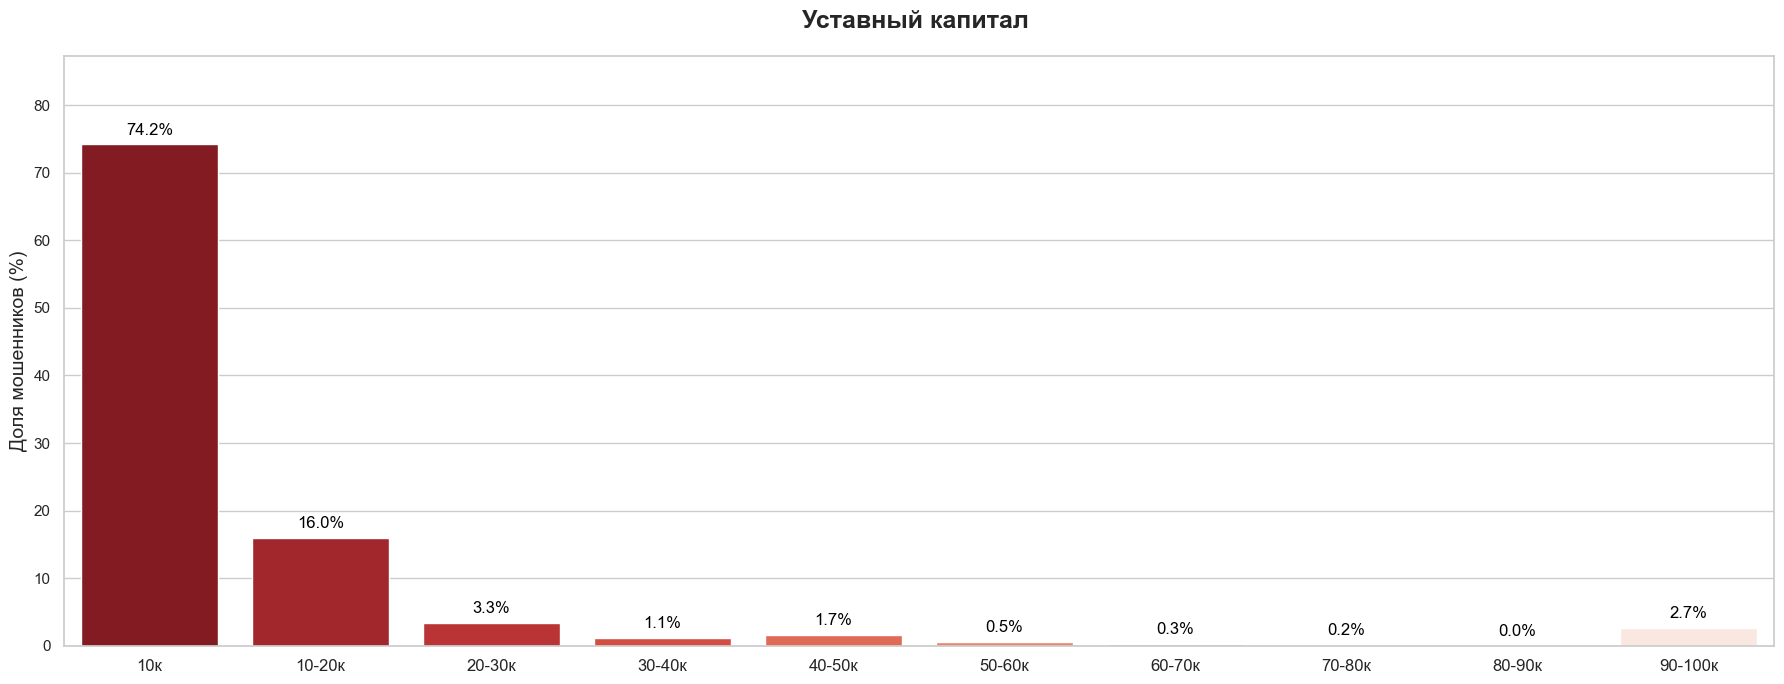

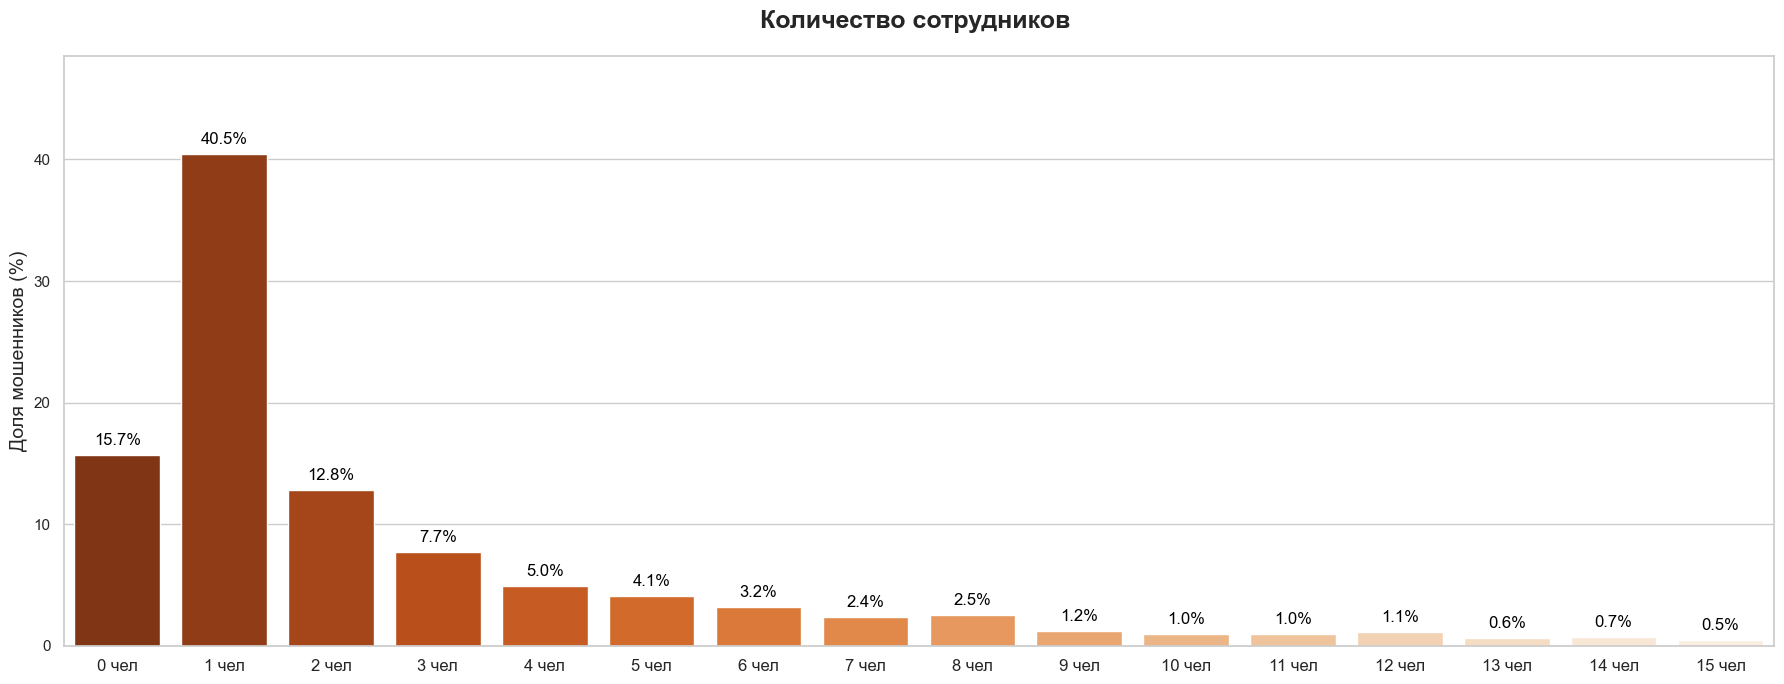

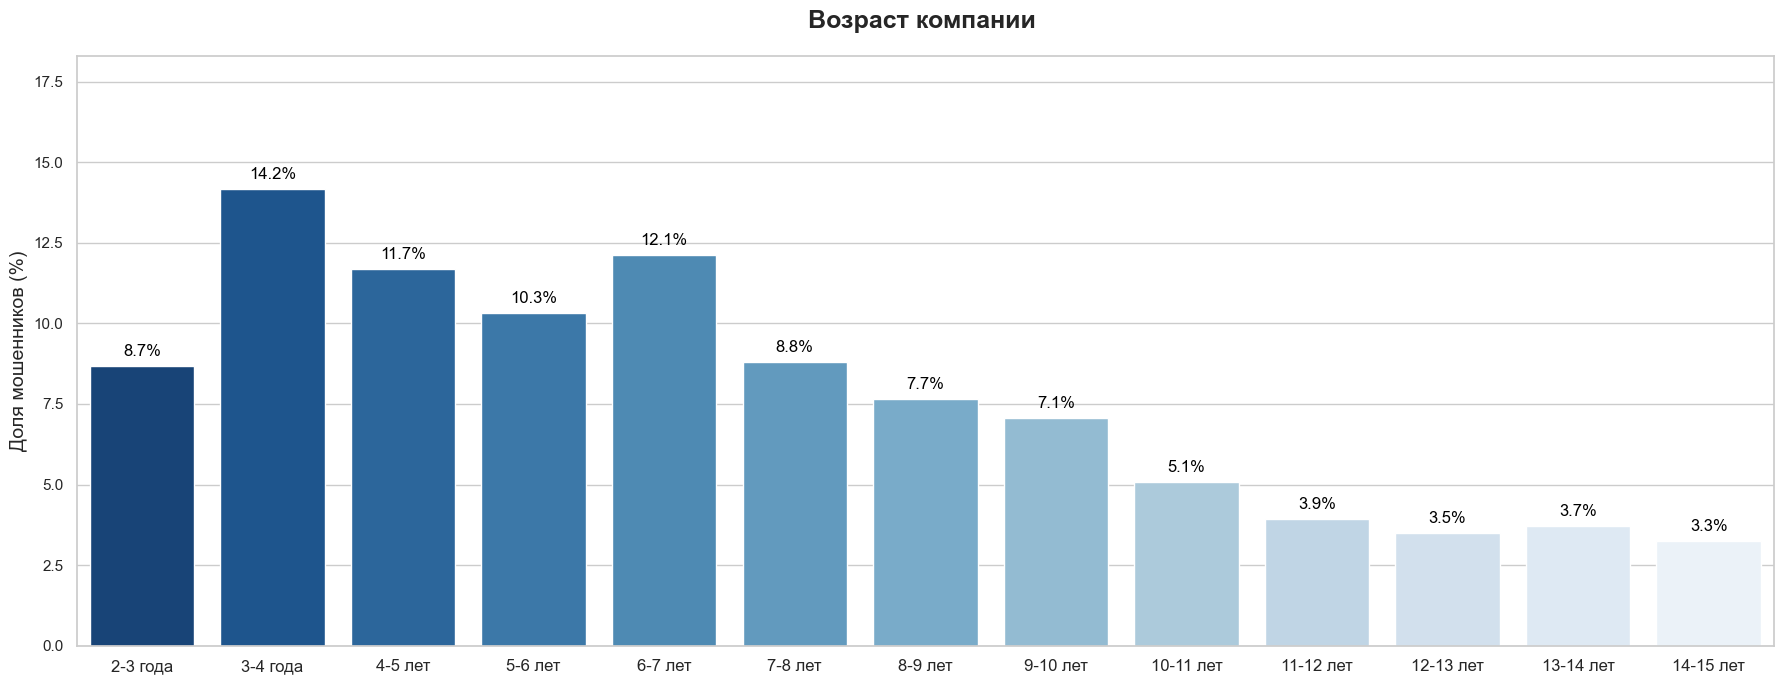

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import urllib.parse
import warnings
warnings.filterwarnings('ignore')


user = 'postgres'
password = '1' 
host = 'localhost'
db_name = 'fraud_db'
safe_pass = urllib.parse.quote_plus(password)
engine = create_engine(f'postgresql://{user}:{safe_pass}@{host}/{db_name}')


query = """
SELECT capital, staff_count, age_years 
FROM fraud_mart 
WHERE is_rnp = 1 AND age_years >= 2
"""
df_full = pd.read_sql(query, engine)


df_fraud = df_full[
    (df_full['age_years'] <= 15) & 
    (df_full['staff_count'] <= 15) & 
    (df_full['capital'] <= 100000)
].copy()



cap_bins = [-1, 10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000]
cap_labels = ['10к', '10-20к', '20-30к', '30-40к', '40-50к', '50-60к', '60-70к', '70-80к', '80-90к', '90-100к']
df_fraud['capital_group'] = pd.cut(df_fraud['capital'], bins=cap_bins, labels=cap_labels)


staff_bins = np.arange(-1, 16, 1) 
staff_labels = [f'{i} чел' for i in range(16)]
df_fraud['staff_group'] = pd.cut(df_fraud['staff_count'], bins=staff_bins, labels=staff_labels)


age_bins = [1.99, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
age_labels = ['2-3 года', '3-4 года', '4-5 лет', '5-6 лет', '6-7 лет', '7-8 лет', '8-9 лет', '9-10 лет', '10-11 лет', '11-12 лет', '12-13 лет', '13-14 лет', '14-15 лет']
df_fraud['age_group'] = pd.cut(df_fraud['age_years'], bins=age_bins, labels=age_labels)


sns.set_theme(style="whitegrid")

def plot_large_bar(col, title, order, color_palette):
   
    plt.figure(figsize=(18, 7))
    
    data = df_fraud[col].value_counts(normalize=True).mul(100).rename('percent').reset_index()
    ax = sns.barplot(data=data, x=col, y='percent', order=order, palette=color_palette)
    
    plt.title(title, fontweight='bold', fontsize=18, pad=20)
    plt.ylabel('Доля мошенников (%)', fontsize=14)
    plt.xlabel('')
    plt.xticks(fontsize=12, rotation=0) 
    
    max_val = data['percent'].max()
    if pd.isna(max_val): max_val = 0
    plt.ylim(0, max_val + max_val * 0.15 + 2) 
    
    for p in ax.patches:
        height = p.get_height()
        if pd.isna(height): height = 0 
        if height > 0:
            ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')
    
    plt.tight_layout()
    plt.show()


plot_large_bar('capital_group', 'Уставный капитал ', cap_labels, 'Reds_r')
plot_large_bar('staff_group', 'Количество сотрудников ', staff_labels, 'Oranges_r')
plot_large_bar('age_group', 'Возраст компании ', age_labels, 'Blues_r')

# Проведенный анализ подтвердил выдвинутую гипотезу частично, выявив аномальные паттерны и степень их влияния на риск попадания в РНП:
**Уставный капитал (Гипотеза подтверждена полностью)**

Данные показывают критическую зависимость: 74.2% всех мошенников имеют минимально допустимый капитал 10 000 руб.

При увеличении капитала до 20-30к доля падает в 22 раза (до 3.3%).

Вывод: Минимальный капитал — основной маркер компаний, не планирующих нести финансовую ответственность.

**Количество сотрудников (Гипотеза подтверждена полностью)** 

Аномальная концентрация риска в сегменте микро-организаций: суммарно 69% нарушителей имеют штат от 0 до 2 человек.

Пик приходится на компании с 1 сотрудником (40.5%).

Вывод: Отсутствие сотрудников — прямой физический барьер для качественного исполнения госконтракта.

**Возраст компании (Гипотеза подтверждена частично)**

График возраста показал размытую картину:

Хотя пик нарушений приходится на молодой бизнес (3-4 года — 14.2%), значительная доля фрода даже у компаний со стажем 6-7 лет (12.1%).

Вывод: В отличие от капитала и штата, возраст не является надежным стоп-фактором.